# Notebook 00b: GEE Data Missingness Assessment (pre-download)

## Overview
This notebook assesses the **daily data availability** of each Google Earth Engine
variable across all cities and the full time period of interest, **before** downloading
any data.

For each combination of city × variable × day, it counts the number of valid (non-NaN)
pixels **within the clipped city boundary** (land-only, sea and lakes removed) and
records the percentage of valid coverage. Results are written incrementally to a CSV
file so that the process can be interrupted and resumed.

## Why use the clipped boundary instead of the bounding box?
The previous version sampled valid pixels over the rectangular bounding box of each
city. This inflated `total_pixels` for coastal cities (e.g. Dakar, Mumbai, Lagos)
because sea pixels — which carry no valid NO₂ or NTL signal — were counted in the
denominator. Using the clipped land-only boundary polygon from notebook 00a gives a
more accurate picture of actual data coverage over the city area of interest.

**Two-step spatial filter:**
1. The bounding box of the clipped boundary is passed to GEE as `filterBounds` — this
   restricts the satellite image download to the relevant tile, keeping GEE calls fast.
2. The returned rectangular image is then re-clipped to the land-only boundary polygon
   before counting valid pixels — so only pixels inside the city boundary contribute
   to `valid_pixels` and `total_pixels`.

## Why this step?
GEE satellite products have irregular temporal coverage:
- **Sentinel-5P NO₂** has daily overpasses but cloud contamination and orbit gaps cause missing data
- **VIIRS NTL** is affected by moonlight and cloud cover
- **ERA5** is a reanalysis product with near-complete coverage but occasional gaps

Assessing missingness first avoids downloading large volumes of data for cities or
periods that are too incomplete to be useful.

## Prerequisites
- Notebook 00a must have been run for all cities so that the clipped boundary files
  exist at `data/raw/{city}/city_boundary/{city}_boundary_clipped.gpkg`.

## Output
A single CSV file: `data/missingness/missingness_{START_DATE}_{END_DATE}.csv`

| Column | Description |
|--------|-------------|
| `city` | City slug |
| `variable` | Variable name (e.g. `no2`) |
| `date` | Date string `YYYY-MM-DD` |
| `valid_pixels` | Non-NaN pixels inside the clipped city boundary |
| `total_pixels` | Total pixels inside the clipped city boundary |
| `valid_pct` | Percentage of valid pixels (0–100) |

## How to use
1. Edit the **`── USER INPUTS ──`** cell below
2. Run all cells — progress is printed per city/variable/day
3. Pass the output CSV to **Notebook 00c** for threshold-based city/period selection

---

## 0 · Initialisation

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import sys
import csv
import time
import warnings
import threading
from pathlib import Path
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

# ── Third-party ───────────────────────────────────────────────────────────────
import ee
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

warnings.filterwarnings('ignore')

# ── Project config ────────────────────────────────────────────────────────────
SRC_PATH = Path().resolve().parent / 'src'
sys.path.append(str(SRC_PATH))
from config import DATA_PATH

print(f'Data root: {DATA_PATH}')

Data root: /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── USER INPUTS  (edit this cell to configure the assessment) ─────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Time range ────────────────────────────────────────────────────────────────
START_DATE = '2025-01-01'
END_DATE   = '2025-12-31'

# ── Cities ────────────────────────────────────────────────────────────────────
# Each entry only needs the city slug. The clipped boundary GeoPackage produced
# by notebook 00a is resolved automatically from DATA_PATH using the convention:
#   data/raw/{city}/city_boundary/{city}_boundary_clipped.gpkg
#
# The bounding box of that boundary is derived at runtime and used as the GEE
# filterBounds region (fast rectangle filter). The boundary polygon itself is
# then used to clip the returned image so that valid_pixels and total_pixels
# reflect only the land area inside the city boundary.
#
# If the clipped boundary file is missing for a city, the notebook will raise
# a clear FileNotFoundError before the GEE calls begin.
CITIES = [
    {"name": "new_york"    },
    {"name": "buenos_aires"},
    {"name": "baghdad"     },
    {"name": "mexico_city" },
    {"name": "abuja"       },
    {"name": "cairo"       },
    {"name": "dakar"       },
    {"name": "lima"        },
    {"name": "mumbai"      },
    # {"name": "cebu"     },
    # {"name": "nairobi"  },

    {"name": "algiers"},
    {"name": "cape_town"},
    {"name": "los_angeles"},
    {"name": "madrid"},
    {"name": "santiago"},
    {"name": "yangon"},

]

# ── GEE collections and bands ─────────────────────────────────────────────────
# Add or comment out variables as needed.
# 'aggregation' is the daily composite method: 'mean' or 'median'.
VARIABLES = [
    {
        "name"        : "no2",
        "collection"  : "COPERNICUS/S5P/OFFL/L3_NO2",
        "band"        : "tropospheric_NO2_column_number_density",
        "aggregation" : "mean",
        "scale_m"     : 1000,
    },
    {
        "name"        : "era5_temp",
        "collection"  : "ECMWF/ERA5_LAND/DAILY_AGGR",
        "band"        : "temperature_2m",
        "aggregation" : "mean",
        "scale_m"     : 11132,   # ERA5-Land native resolution ~11km
    },
    {
        "name"        : "wind_speed",
        "collection"  : "ECMWF/ERA5_LAND/DAILY_AGGR",
        # Derived variable: combines two bands PER IMAGE as sqrt(u^2 + v^2)
        # before the daily mean/median composite — see 'derive' below and the
        # updated assess_day() in the CORE FUNCTIONS cell. 
        "bands"       : ["u_component_of_wind_10m", "v_component_of_wind_10m"],
        "derive"      : "wind_speed",
        "aggregation" : "mean",
        "scale_m"     : 11132,   # same native resolution as era5_temp
    },
    # {
    #     "name"        : "ntl",
    #     "collection"  : "NASA/VIIRS/002/VNP46A2",
    #     "band"        : "DNB_BRDF_Corrected_NTL",
    #     "aggregation" : "mean",
    #     "scale_m"     : 1000,
    # },
]

# ── GEE settings ──────────────────────────────────────────────────────────────
# Your GEE cloud project name
GEE_PROJECT = 'gen-lang-client-0643926912'   # ← EDIT THIS

# Scale (metres) used to sample pixels for the validity count.
# Coarser = faster; does not need to match the download resolution.
SAMPLE_SCALE_M = 1000

# Maximum number of cities processed in parallel.
# Set to 1 for sequential processing (safer for GEE quota).
MAX_WORKERS = 3

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
# ── GEE authentication & initialisation ───────────────────────────────────────
# Comment out ee.Authenticate() after the first successful run.
ee.Authenticate()
ee.Initialize(project=GEE_PROJECT)
print('Earth Engine initialised.')

Earth Engine initialised.


In [4]:
# ── Output path setup ─────────────────────────────────────────────────────────
MISSINGNESS_DIR = DATA_PATH / 'missingness'
MISSINGNESS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = MISSINGNESS_DIR / f'missingness_{START_DATE}_{END_DATE}.csv'
print(f'Output CSV : {OUTPUT_CSV}')

# ── Generate full date list ───────────────────────────────────────────────────
ALL_DATES = (
    pd.date_range(START_DATE, END_DATE, freq='D')
    .strftime('%Y-%m-%d')
    .tolist()
)
print(f'Date range : {START_DATE} → {END_DATE} ({len(ALL_DATES)} days)')
print(f'Cities     : {[c["name"] for c in CITIES]}')
print(f'Variables  : {[v["name"] for v in VARIABLES]}')
print(f'Total rows : {len(ALL_DATES) * len(CITIES) * len(VARIABLES):,}')
# ── Pre-flight: verify clipped boundary files exist for all cities ────────────
# Fail fast before any GEE calls are made so the user knows immediately
# which cities need to be processed in notebook 00a first.
print()
print('Checking clipped boundary files...')
missing = []
for city in CITIES:
    p = DATA_PATH / 'raw' / city['name'] / 'city_boundary' / f'{city["name"]}_boundary_clipped.gpkg'
    if p.exists():
        print(f'  ✅  {city["name"]}')
    else:
        print(f'  ❌  {city["name"]} — missing: {p}')
        missing.append(city['name'])

if missing:
    raise FileNotFoundError(
        f"\nClipped boundary files missing for: {missing}\n"
        f"Run notebook 00a for these cities before proceeding."
    )
print('\nAll boundary files found. Ready to run.')

Output CSV : /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/missingness_2025-01-01_2025-12-31.csv
Date range : 2025-01-01 → 2025-12-31 (365 days)
Cities     : ['new_york', 'buenos_aires', 'baghdad', 'mexico_city', 'abuja', 'cairo', 'dakar', 'lima', 'mumbai', 'cebu', 'nairobi', 'algiers', 'cape_town', 'los_angeles', 'madrid', 'santiago', 'yangon']
Variables  : ['no2']
Total rows : 6,205

Checking clipped boundary files...
  ✅  new_york
  ✅  buenos_aires
  ✅  baghdad
  ✅  mexico_city
  ✅  abuja
  ✅  cairo
  ✅  dakar
  ✅  lima
  ✅  mumbai
  ✅  cebu
  ✅  nairobi
  ✅  algiers
  ✅  cape_town
  ✅  los_angeles
  ✅  madrid
  ✅  santiago
  ✅  yangon

All boundary files found. Ready to run.


---
## 1 · Missingness Assessment Functions

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CORE FUNCTIONS  (do not edit)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import geopandas as gpd
import json as _json


def load_city_boundary(city_name: str) -> tuple:
    """
    Load the clipped land-only city boundary produced by notebook 00a and
    return both an ee.Geometry bounding box (for GEE filterBounds) and an
    ee.Geometry polygon (for post-image clipping).

    The clipped boundary file is resolved from DATA_PATH using the convention:
        data/raw/{city}/city_boundary/{city}_boundary_clipped.gpkg

    Two-step spatial filter rationale:
        1. bbox_geom  → passed to GEE filterBounds / reduceRegion for efficiency;
                        keeps GEE calls fast by restricting to the relevant tile.
        2. poly_geom  → used as the mask inside assess_day so that only pixels
                        within the land boundary contribute to valid_pixels and
                        total_pixels. Sea and lake pixels — outside the clipped
                        polygon — are excluded from both counts.

    Parameters
    ----------
    city_name : city slug matching the directory name under data/raw/

    Returns
    -------
    (bbox_geom, poly_geom, gdf)
        bbox_geom : ee.Geometry.Rectangle  — bounding box of the clipped boundary
        poly_geom : ee.Geometry            — land-only boundary polygon(s)
        gdf       : GeoDataFrame           — clipped boundary in EPSG:4326

    Raises
    ------
    FileNotFoundError if the clipped boundary file does not exist.
    """
    boundary_path = (
        DATA_PATH / 'raw' / city_name / 'city_boundary'
        / f'{city_name}_boundary_clipped.gpkg'
    )

    if not boundary_path.exists():
        raise FileNotFoundError(
            f"Clipped boundary not found for '{city_name}'.\n"
            f"  Expected: {boundary_path}\n"
            f"  Run notebook 00a first to generate the clipped boundary."
        )

    gdf = gpd.read_file(boundary_path).to_crs('EPSG:4326')

    # ── Bounding box for GEE filterBounds ─────────────────────────────────────
    minx, miny, maxx, maxy = gdf.total_bounds
    bbox_geom = ee.Geometry.Rectangle([minx, miny, maxx, maxy])

    # ── Land-only polygon for post-image clipping ─────────────────────────────
    # Dissolve all features to one geometry, convert to GeoJSON, then to
    # ee.Geometry so GEE can use it as a mask inside reduceRegion.
    if hasattr(gdf.geometry, 'union_all'):
        merged = gdf.geometry.union_all()
    else:
        merged = gdf.unary_union

    # ee.Geometry.MultiPolygon / Polygon from GeoJSON
    poly_geom = ee.Geometry(
        _json.loads(
            gpd.GeoDataFrame(geometry=[merged], crs='EPSG:4326')
            .to_json()
        )['features'][0]['geometry']
    )

    return bbox_geom, poly_geom, gdf


def assess_day(
    date_str    : str,
    collection  : str,
    aggregation : str,
    bbox_geom   : 'ee.Geometry',
    poly_geom   : 'ee.Geometry',
    scale_m     : int,
    band        : str = None,
    bands       : list = None,
    derive      : str  = None,
) -> tuple:
    """
    Count valid (non-NaN) vs total pixels for a single day, clipped to the
    land-only city boundary polygon.

    The two-geometry approach:
        - bbox_geom  is used for filterBounds (fast spatial pre-filter on GEE)
        - poly_geom  is used as the reduceRegion geometry so only pixels inside
                     the land boundary are counted — sea and lake pixels are
                     excluded from both valid_pixels and total_pixels.

    This gives a valid_pct that reflects coverage over the actual city area,
    not the rectangular bounding box which may include large water bodies.

    Two variable shapes are supported, mirroring 00d_gee_download.ipynb:
        - Single-band        : pass `band` (a string). Daily composite is the
                                mean/median of that band.
        - Derived/multi-band : pass `bands` (a list) and `derive` naming the
                                per-image derivation applied BEFORE the daily
                                composite. Currently supported:
                                  'wind_speed' -> sqrt(u^2 + v^2) from
                                  ['u_component_of_wind_10m', 'v_component_of_wind_10m']
                                Deriving per-image (rather than from the
                                daily-mean u/v) matters: averaging u and v
                                first and then taking the magnitude can cancel
                                out opposing wind directions within the day,
                                understating true mean wind speed.

    Parameters
    ----------
    date_str    : 'YYYY-MM-DD'
    collection  : GEE ImageCollection ID
    aggregation : 'mean' or 'median' daily composite
    bbox_geom   : ee.Geometry.Rectangle — used for filterBounds
    poly_geom   : ee.Geometry — land-only polygon used for reduceRegion
    scale_m     : sampling resolution in metres
    band        : single band name to sample (mutually exclusive with bands/derive)
    bands       : list of band names to sample (used with derive)
    derive      : name of the per-image derivation to apply (e.g. 'wind_speed')

    Returns
    -------
    (valid_pixels, total_pixels, valid_pct)
    Returns (0, 0, 0.0) if no images exist for that day.
    """
    next_day = (
        datetime.strptime(date_str, '%Y-%m-%d') + timedelta(days=1)
    ).strftime('%Y-%m-%d')

    # ── Resolve single-band vs derived multi-band selection ──────────────────
    if derive == 'wind_speed':
        u_band, v_band = bands

        def _select_and_derive(img):
            # Per-image vector magnitude, computed BEFORE daily aggregation —
            # see rationale in the docstring above.
            u = img.select(u_band)
            v = img.select(v_band)
            speed = u.pow(2).add(v.pow(2)).sqrt().rename('wind_speed_ms')
            return speed

        select_bands = bands
    elif derive is not None:
        raise ValueError(
            f"Unknown derive type '{derive}'. Supported: 'wind_speed'."
        )
    else:
        select_bands = band
        _select_and_derive = None  # plain single-band path, unchanged behaviour

    # Build daily composite — filterBounds uses the fast bbox for tile selection
    col = (
        ee.ImageCollection(collection)
        .select(select_bands)
        .filterDate(date_str, next_day)
        .filterBounds(bbox_geom)
    )

    if _select_and_derive is not None:
        # Map the per-image derivation (e.g. wind speed) BEFORE compositing
        col = col.map(_select_and_derive)

    image = col.mean() if aggregation == 'mean' else col.median()

    # Constant image to count total pixels (always valid, used as denominator)
    total_img = ee.Image.constant(1).rename('total')

    # Stack: band value + constant 1
    stacked = image.rename('value').addBands(total_img)

    # reduceRegion over poly_geom — only pixels inside the land boundary are
    # counted. Masked/NaN pixels are ignored by ee.Reducer.count() automatically.
    stats = stacked.reduceRegion(
        reducer  = ee.Reducer.count(),
        geometry = poly_geom,          # ← land-only polygon, not bbox
        scale    = scale_m,
        maxPixels= 1e9,
    ).getInfo()

    valid_pixels = stats.get('value', 0) or 0
    total_pixels = stats.get('total', 0) or 0
    valid_pct    = round(100.0 * valid_pixels / total_pixels, 2) if total_pixels > 0 else 0.0

    return (valid_pixels, total_pixels, valid_pct)


# Thread-safe CSV writer lock — prevents concurrent threads corrupting the file
_csv_lock = threading.Lock()


def load_completed_rows(csv_path: Path) -> set:
    """
    Load already-completed (city, variable, date) tuples from the CSV.
    Used to skip rows on resume after interruption.

    Parameters
    ----------
    csv_path : Path to the output CSV

    Returns
    -------
    Set of (city, variable, date) tuples already written
    """
    if not csv_path.exists():
        return set()
    df = pd.read_csv(csv_path)
    return set(zip(df['city'], df['variable'], df['date']))


def write_row(csv_path: Path, row: dict) -> None:
    """
    Append a single result row to the CSV in a thread-safe manner.
    Creates the file with a header if it does not yet exist.

    Parameters
    ----------
    csv_path : Path to the output CSV
    row      : dict with keys: city, variable, date, valid_pixels,
                               total_pixels, valid_pct
    """
    fieldnames = ['city', 'variable', 'date', 'valid_pixels', 'total_pixels', 'valid_pct']
    write_header = not csv_path.exists()

    with _csv_lock:
        with open(csv_path, 'a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            if write_header:
                writer.writeheader()
            writer.writerow(row)


def assess_city_variable(
    city        : dict,
    variable    : dict,
    dates       : list,
    csv_path    : Path,
    completed   : set,
    scale_m     : int,
) -> None:
    """
    Run the full missingness assessment for one city × variable combination.

    Loads the clipped boundary once per city × variable call, then iterates
    over all dates. Skips rows already in the CSV (resume support) and writes
    each result immediately after computation.

    Parameters
    ----------
    city      : city dict with key 'name' (slug)
    variable  : variable dict with keys 'name', 'collection', 'aggregation',
                and either 'band' (single-band) or 'bands' + 'derive'
                (derived multi-band, e.g. wind_speed)
    dates     : list of 'YYYY-MM-DD' strings
    csv_path  : output CSV path
    completed : set of (city, variable, date) tuples already written
    scale_m   : sampling resolution in metres
    """
    city_name = city['name']
    var_name  = variable['name']

    # Load clipped boundary once — reused across all dates for this city
    # bbox_geom → filterBounds (fast GEE tile filter)
    # poly_geom → reduceRegion mask (land-only pixel counting)
    bbox_geom, poly_geom, _ = load_city_boundary(city_name)

    n_skip = 0
    n_done = 0

    for date_str in dates:
        # Skip if already written (resume after interruption)
        if (city_name, var_name, date_str) in completed:
            n_skip += 1
            continue

        try:
            valid_px, total_px, valid_pct = assess_day(
                date_str    = date_str,
                collection  = variable['collection'],
                aggregation = variable['aggregation'],
                bbox_geom   = bbox_geom,
                poly_geom   = poly_geom,
                scale_m     = scale_m,
                band        = variable.get('band'),
                bands       = variable.get('bands'),
                derive      = variable.get('derive'),
            )
        except Exception as e:
            # On GEE error, record as 0 valid pixels and continue
            print(f'  WARNING [{city_name}/{var_name}/{date_str}]: {e}')
            valid_px, total_px, valid_pct = 0, 0, 0.0

        write_row(csv_path, {
            'city'        : city_name,
            'variable'    : var_name,
            'date'        : date_str,
            'valid_pixels': valid_px,
            'total_pixels': total_px,
            'valid_pct'   : valid_pct,
        })
        n_done += 1

    print(f'  [{city_name} / {var_name}] done — {n_done} assessed, {n_skip} skipped (cached)')


print('Functions loaded.')

Functions loaded.


---
## 2 · Run Assessment

Processes all cities in parallel (up to `MAX_WORKERS` at a time). Each city runs all variables sequentially to avoid overloading GEE. Results are written to the CSV as they complete — safe to interrupt and resume.

In [6]:
# ── Load already-completed rows (supports resume after interruption) ───────────
completed_rows = load_completed_rows(OUTPUT_CSV)
print(f'Already completed rows in CSV : {len(completed_rows):,}')
print(f'Remaining                     : {len(ALL_DATES) * len(CITIES) * len(VARIABLES) - len(completed_rows):,}')


def process_city(city: dict) -> None:
    """
    Worker function submitted to the thread pool.
    Runs all variables sequentially for one city.
    """
    print(f'\n[START] {city["name"]} — {len(VARIABLES)} variable(s)')
    for variable in VARIABLES:
        assess_city_variable(
            city      = city,
            variable  = variable,
            dates     = ALL_DATES,
            csv_path  = OUTPUT_CSV,
            completed = completed_rows,
            scale_m   = SAMPLE_SCALE_M,
        )
    print(f'[DONE]  {city["name"]}')


# ── Run with thread pool ───────────────────────────────────────────────────────
t0 = time.time()
print(f'Starting assessment with MAX_WORKERS={MAX_WORKERS} …\n')

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(process_city, city): city['name'] for city in CITIES}
    for future in as_completed(futures):
        city_name = futures[future]
        try:
            future.result()
        except Exception as e:
            print(f'ERROR in city {city_name}: {e}')

elapsed = time.time() - t0
print(f'\nAssessment complete in {elapsed/60:.1f} min')
print(f'Output: {OUTPUT_CSV}')

Already completed rows in CSV : 4,121
Remaining                     : 2,084
Starting assessment with MAX_WORKERS=3 …


[START] new_york — 1 variable(s)

[START] buenos_aires — 1 variable(s)

[START] baghdad — 1 variable(s)
  [new_york / no2] done — 0 assessed, 365 skipped (cached)
[DONE]  new_york

[START] mexico_city — 1 variable(s)
  [baghdad / no2] done — 0 assessed, 365 skipped (cached)
[DONE]  baghdad

[START] abuja — 1 variable(s)
  [buenos_aires / no2] done — 0 assessed, 365 skipped (cached)
[DONE]  buenos_aires

[START] cairo — 1 variable(s)
  [mexico_city / no2] done — 0 assessed, 365 skipped (cached)
[DONE]  mexico_city

[START] dakar — 1 variable(s)
  [abuja / no2] done — 0 assessed, 365 skipped (cached)
[DONE]  abuja

[START] lima — 1 variable(s)
  [dakar / no2] done — 0 assessed, 365 skipped (cached)
[DONE]  dakar

[START] mumbai — 1 variable(s)
  [cairo / no2] done — 0 assessed, 365 skipped (cached)
[DONE]  cairo

[START] cebu — 1 variable(s)
  [cebu / no2] done — 0 asses

---
## 3 · Results Summary & Visualisation

Load the completed CSV and display:
1. A summary table of mean valid coverage per city × variable
2. One heatmap per variable (rows = cities, columns = days)

In [7]:
# ── Load results ──────────────────────────────────────────────────────────────
df = pd.read_csv(OUTPUT_CSV, parse_dates=['date'])
df = df.sort_values(['city', 'variable', 'date']).reset_index(drop=True)

print(f'Rows loaded: {len(df):,}')
print(f'Cities     : {sorted(df["city"].unique())}')
print(f'Variables  : {sorted(df["variable"].unique())}')
print(f'Date range : {df["date"].min().date()} → {df["date"].max().date()}')

Rows loaded: 6,205
Cities     : ['abuja', 'algiers', 'baghdad', 'buenos_aires', 'cairo', 'cape_town', 'cebu', 'dakar', 'lima', 'los_angeles', 'madrid', 'mexico_city', 'mumbai', 'nairobi', 'new_york', 'santiago', 'yangon']
Variables  : ['no2']
Date range : 2025-01-01 → 2025-12-31


In [8]:
# ── Summary table: mean valid % per city × variable ───────────────────────────
summary = (
    df.groupby(['city', 'variable'])['valid_pct']
    .agg(
        mean_valid_pct = 'mean',
        days_above_50  = lambda x: (x >= 50).sum(),
        days_above_70  = lambda x: (x >= 70).sum(),
        days_zero      = lambda x: (x == 0).sum(),
    )
    .round(1)
    .reset_index()
)

print('\n── Coverage summary ──────────────────────────────────────────────────────')
print(summary.to_string(index=False))


── Coverage summary ──────────────────────────────────────────────────────
        city variable  mean_valid_pct  days_above_50  days_above_70  days_zero
       abuja      no2            55.5            203            177         73
     algiers      no2            68.8            256            233         65
     baghdad      no2            85.9            316            307         17
buenos_aires      no2            62.1            233            199         52
       cairo      no2            83.0            321            296         12
   cape_town      no2            72.4            269            249         40
        cebu      no2            32.4            110             43         61
       dakar      no2            74.8            276            257         42
        lima      no2            63.9            239            193         19
 los_angeles      no2            80.1            297            280         20
      madrid      no2            59.1            220   

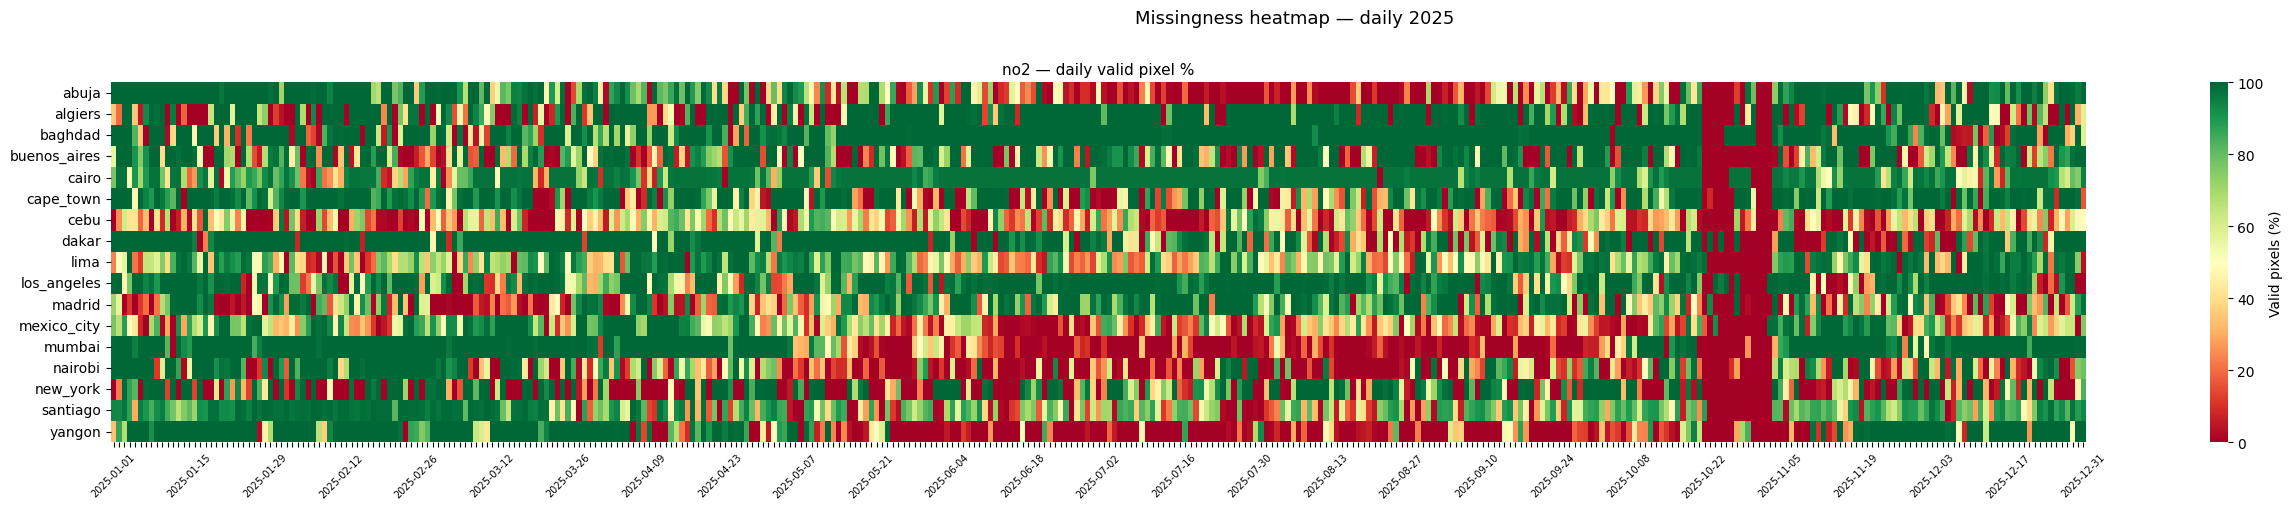

Saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/missingness_heatmap_daily_2025-01-01_2025-12-31.pdf


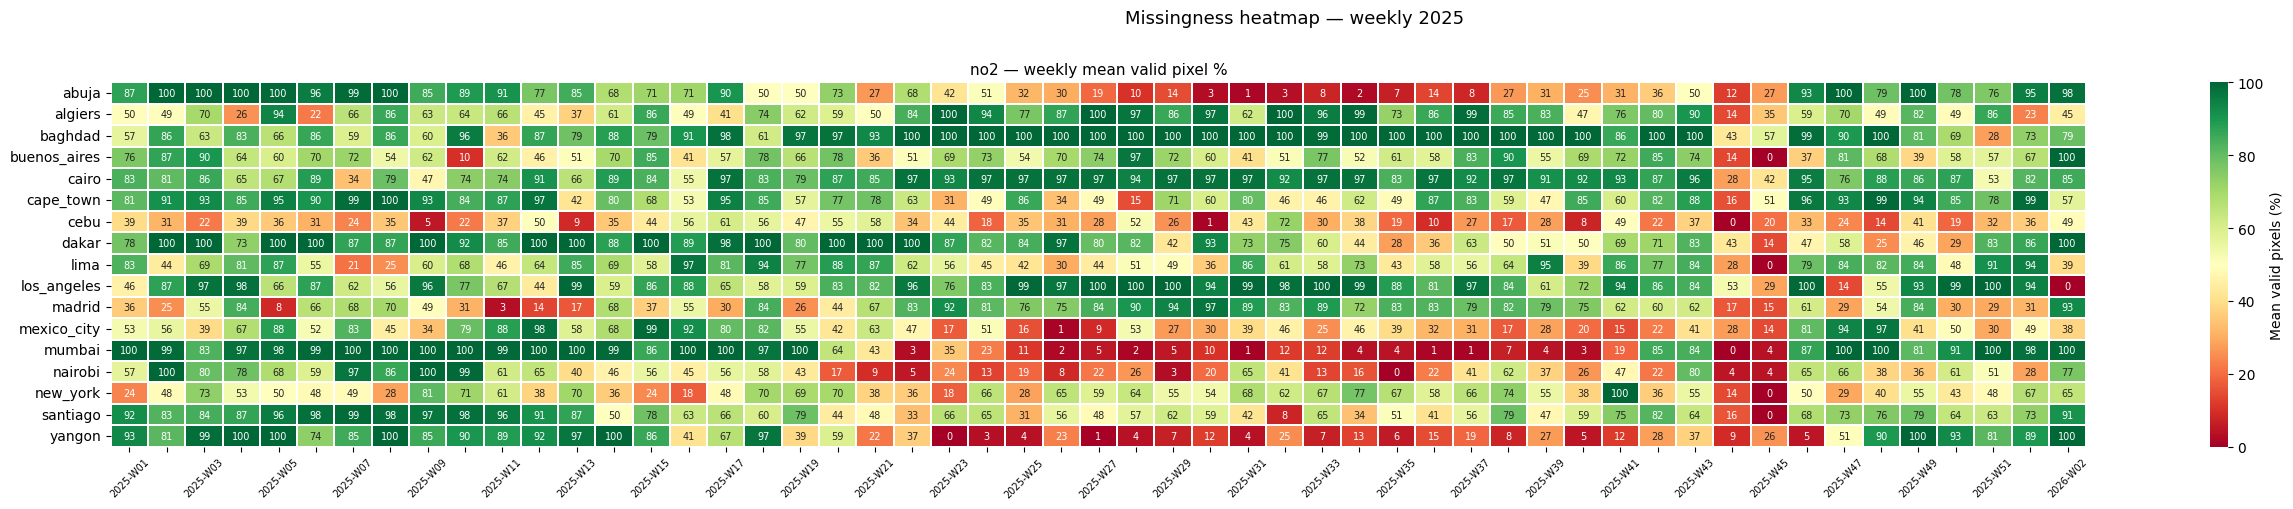

Saved → /Users/sergimarsol/Documentos/0. UNIVERSITAT/1. Imperial/4. Group Design Project/WB Project/data/missingness/missingness_heatmap_weekly_2025-01-01_2025-12-31.pdf


In [9]:
import seaborn as sns

# ── Load results ──────────────────────────────────────────────────────────────
df = pd.read_csv(OUTPUT_CSV, parse_dates=['date'])
df = df.sort_values(['city', 'variable', 'date']).reset_index(drop=True)

out_dir = MISSINGNESS_DIR

# ── Daily dataframe ───────────────────────────────────────────────────────────
daily_df = df.copy()
daily_df['valid_pct_filled'] = daily_df['valid_pct'].fillna(0)

# ── Weekly aggregation ────────────────────────────────────────────────────────
weekly_df = (
    df.groupby(['city', 'variable', pd.Grouper(key='date', freq='W-MON')])
    ['valid_pct']
    .mean()
    .reset_index()
    .rename(columns={'valid_pct': 'mean_valid_pct'})
)
weekly_df['year_week'] = weekly_df['date'].dt.strftime('%Y-W%V')

city_names = [c['name'] for c in CITIES]

# ── Daily heatmap ─────────────────────────────────────────────────────────────
vars_to_plot = daily_df['variable'].unique()
n_vars = len(vars_to_plot)
fig, axes = plt.subplots(n_vars, 1, figsize=(26, 5 * n_vars))
if n_vars == 1:
    axes = [axes]

for ax, var in zip(axes, vars_to_plot):
    pivot = (
        daily_df[(daily_df['variable'] == var) & (daily_df['city'].isin(city_names))]
        .pivot(index='city', columns='date', values='valid_pct_filled')
    )
    pivot.columns = [str(c)[:10] for c in pivot.columns]
    n_cols = len(pivot.columns)
    step   = max(1, n_cols // 26)
    xtick_labels = [c if i % step == 0 else '' for i, c in enumerate(pivot.columns)]
    sns.heatmap(
        pivot,
        ax          = ax,
        vmin        = 0,
        vmax        = 100,
        cmap        = 'RdYlGn',
        linewidths  = 0,
        cbar_kws    = {'label': 'Valid pixels (%)'},
        xticklabels = xtick_labels,
    )
    ax.set_title(f'{var} — daily valid pixel %', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=45)

plt.suptitle(f'Missingness heatmap — daily {START_DATE[:4]}', fontsize=13, y=1.01)
plt.tight_layout()
heatmap_path = out_dir / f'missingness_heatmap_daily_{START_DATE}_{END_DATE}.pdf'
plt.savefig(heatmap_path, bbox_inches='tight')
plt.show()
print(f'Saved → {heatmap_path}')

# ── Weekly heatmap ────────────────────────────────────────────────────────────
vars_to_plot = weekly_df['variable'].unique()
n_vars = len(vars_to_plot)
fig, axes = plt.subplots(n_vars, 1, figsize=(26, 5 * n_vars))
if n_vars == 1:
    axes = [axes]

for ax, var in zip(axes, vars_to_plot):
    pivot = (
        weekly_df[(weekly_df['variable'] == var) & (weekly_df['city'].isin(city_names))]
        .pivot(index='city', columns='year_week', values='mean_valid_pct')
    )
    n_cols = len(pivot.columns)
    step   = max(1, n_cols // 26)
    xtick_labels = [c if i % step == 0 else '' for i, c in enumerate(pivot.columns)]
    sns.heatmap(
        pivot,
        ax          = ax,
        vmin        = 0,
        vmax        = 100,
        cmap        = 'RdYlGn',
        linewidths  = 0.3,
        cbar_kws    = {'label': 'Mean valid pixels (%)'},
        xticklabels = xtick_labels,
        annot       = True,
        fmt         = '.0f',
        annot_kws   = {'size': 7},
    )
    ax.set_title(f'{var} — weekly mean valid pixel %', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=45)

plt.suptitle(f'Missingness heatmap — weekly {START_DATE[:4]}', fontsize=13, y=1.01)
plt.tight_layout()
heatmap_path = out_dir / f'missingness_heatmap_weekly_{START_DATE}_{END_DATE}.pdf'
plt.savefig(heatmap_path, bbox_inches='tight')
plt.show()
print(f'Saved → {heatmap_path}')